<font size="3">**Tarea 1 2026**</font>

Constanza Luarte Salazar
2022428147

### 1.1 Librerías y carga de base de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import poisson as sp_poisson
import warnings
warnings.filterwarnings("ignore")

### 1.1 Cargar base de datos, revisar tipos de datos, incosistencias y valores faltantes

In [2]:
# Cargar base de datos 
df = pd.read_csv('student_productivity.csv', delimiter=",", decimal='.')
# Establecer student_id como índice del DataFrame 
df.set_index('student_id', inplace=True)

print(f'─── Dimensiones del DataFrame  ───')
print(f' {df.shape}\n')
di=df.shape # Para guardar dimensiones iniciales y compararlo tras limpieza e imputación

print("\n─── Tipos de datos ───")
print(df.dtypes.to_string())

print("\n─── Nulos por columna ─────")
print(df.isnull().sum())

# Revisar unique de las columas categóricas (object)
for col in df.select_dtypes(include='object').columns:
    print(f"Categorias en {col}: {df[col].unique()}")



─── Dimensiones del DataFrame  ───
 (5621, 21)


─── Tipos de datos ───
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64

─── Nulos por columna ─────
age                      648
gender                   558
academic_level           630
study_hours              574
self_study_hours         667
online_classes_hours     682
social_media_hours       656
gaming_hours            

### 1.2 Limpieza y estandarización

| Variable | Problema detectado | Decisión |
|---|---|---|
| drug_use | 72.99 % de faltantes | Eliminar columna  |
| exercise_minutes | Es de tipo object; 602 obs. contienen el sufijo ' min' (ej. '42.0 min') | Limpiar sufijo y convertir a numérico. Se elimina esta columna y en su lugar se usa exercise_hours |
|exercise_hours| Exercise_minutes no comparte la misma unidad de medida que las demás (horas) | Crear otra columna a partir de Exercise_minutes, convertirla a horas (dividir en 60)
| academic_level | Espacios en blanco al final generan 7 pseudo-categorías en lugar de 3 | Quitar espacios en blanco |
| part_time_job | Capitalización inconsistente: `'Yes'`, `'yes'`, `'No'`, `'no'` | Normalizar a minúsculas y mapear a binaria {0, 1} |
| exam_score | Datos faltantes |  Al ser la variable binaria, se descartan las filas con valores nulos de exam_score de la base de datos |
| took_exam | 1.0 indica ausencia al examen, no una nota real | Crear la variable binaria took_exam. `took_exam` = 1 si `exam_score > 1.0`, 0 en caso contrario |
| study_hours | Ambigüedad de definición: en ~49 % de observaciones, `study_hours < self_study_hours + online_classes_hours` | Se decide utilizar solo study_hours en el modelo |
| part_time_job, upcoming_deadline | Nulos estructurales (~12–13 %) | Se comprobó que imputar nulos introduce sesgo, entonces se decide realizar una eliminación por lista.  |





In [3]:
df = df.dropna(subset=['exam_score']) # Eliminar nulos de la variable dependiente 
df = df.drop_duplicates()             # Eliminar filas duplicadas en caso de existir 
df = df.drop('drug_use', axis=1)      # Eliminar la columna drug_use por su alto porcentaje de nulos (70% )
di2=df.shape

# Manipulación de variables
df['exercise_minutes'] = df['exercise_minutes'].str.replace(' min', '', regex=False) # Quitar " min" de exercise_minutes
df['exercise_hours'] = pd.to_numeric(df['exercise_minutes'], errors='coerce') / 60   # Convertirlo numerico y a horas
df['academic_level'] = df['academic_level'].str.strip()                              # Quitar espacios de academic_level
df['part_time_job'] = df['part_time_job'].str.strip().str.lower()                    # Dejar part_time_job en minuscula

# Creación de variables binarias 
df = df.dropna(subset=["exam_score"])
df["took_exam"] = (df["exam_score"] != 1.0).astype(int)      # 1.0 en exam_score indica que no rindió (1: rindió examen, 0: no)  
print(df["took_exam"].value_counts(normalize=True).round(2))
       
df['part_time_job'] = df['part_time_job'].map({'yes': 1, 'no': 0}) # (1: tiene trabajo a tiempo parcial, 0: no)
df['gamer'] = np.where(df['gaming_hours'] == 0, 0, 1)              # 0 en gaming_hours indica que no es gamer. (1: es gamer, 0: no)
df.loc[df['gaming_hours'].isna(), 'gamer'] = np.nan                # Si gaming_hours es nan, gamer también debe ser nan

# Eliminar columnas     
df.drop('exercise_minutes', axis=1, inplace=True)             # Se usará exercise_hours en su lugar
print(f"\nDimensiones tras limpieza inicial: {df.shape}")


took_exam
1    0.91
0    0.09
Name: proportion, dtype: float64

Dimensiones tras limpieza inicial: (4912, 22)


### 1.3 Estadísticas descriptivas

In [4]:
print(" Descriptivas de variables numéricas ")
num_cols = df.select_dtypes(include="number").columns.drop(["took_exam", "exam_score"], errors='ignore')
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurt()
desc.columns.name = "Estadísticos"
pd.options.display.float_format = '{:.2f}'.format
desc[["count", "mean", "std", "min", "50%", "max", "skewness", "kurtosis"]]

 Descriptivas de variables numéricas 


Estadísticos,count,mean,std,min,50%,max,skewness,kurtosis
age,4690.00,20.51,2.87,16.00,21.00,25.00,-0.01,-1.23
study_hours,4742.00,4.53,1.82,0.00,4.53,11.84,0.06,-0.13
self_study_hours,4700.00,2.48,1.18,0.00,2.48,7.41,0.08,-0.31
online_classes_hours,4698.00,2.01,0.98,0.00,2.01,6.00,0.12,-0.26
social_media_hours,4696.00,3.00,1.47,0.00,2.98,8.28,0.12,-0.21
gaming_hours,4710.00,1.57,1.11,0.00,1.49,5.64,0.43,-0.36
sleep_hours,4760.00,7.03,1.16,4.00,7.03,10.00,-0.00,-0.15
screen_time_hours,4774.00,6.98,2.49,1.00,6.96,15.30,-0.00,-0.24
caffeine_intake_mg,4740.00,250.92,144.04,0.00,251.00,499.00,-0.02,-1.19
part_time_job,4672.00,0.50,0.50,0.00,0.00,1.00,0.00,-2.00


### 1.4 Distribuciones y detección de outliers


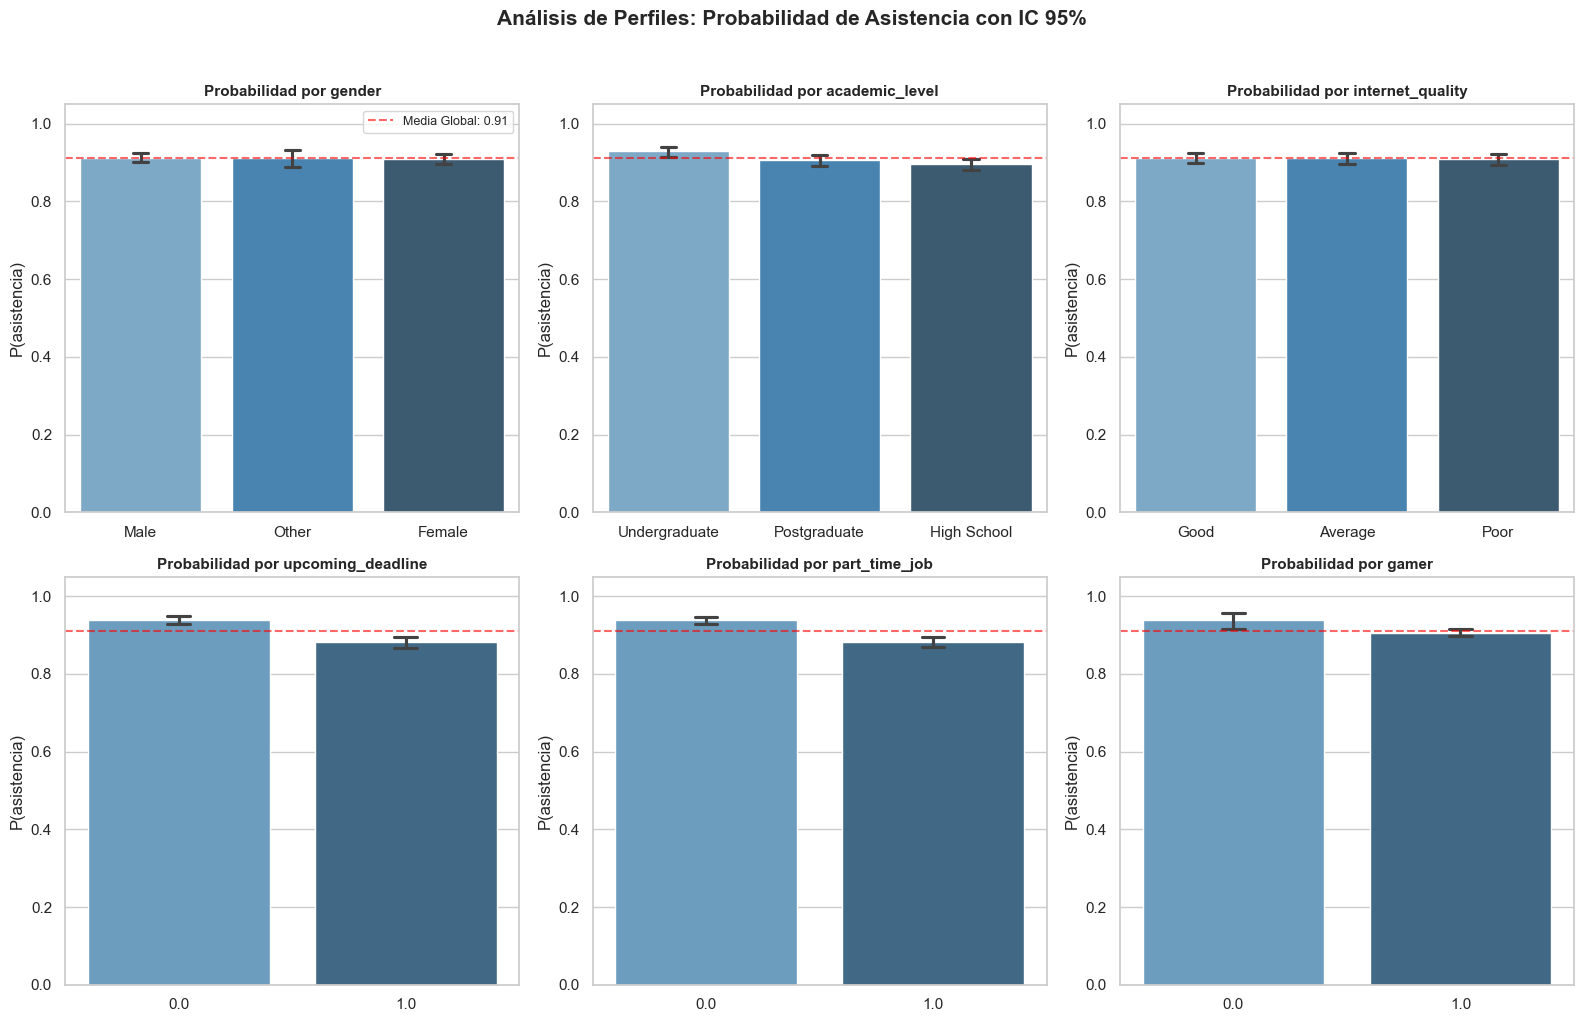

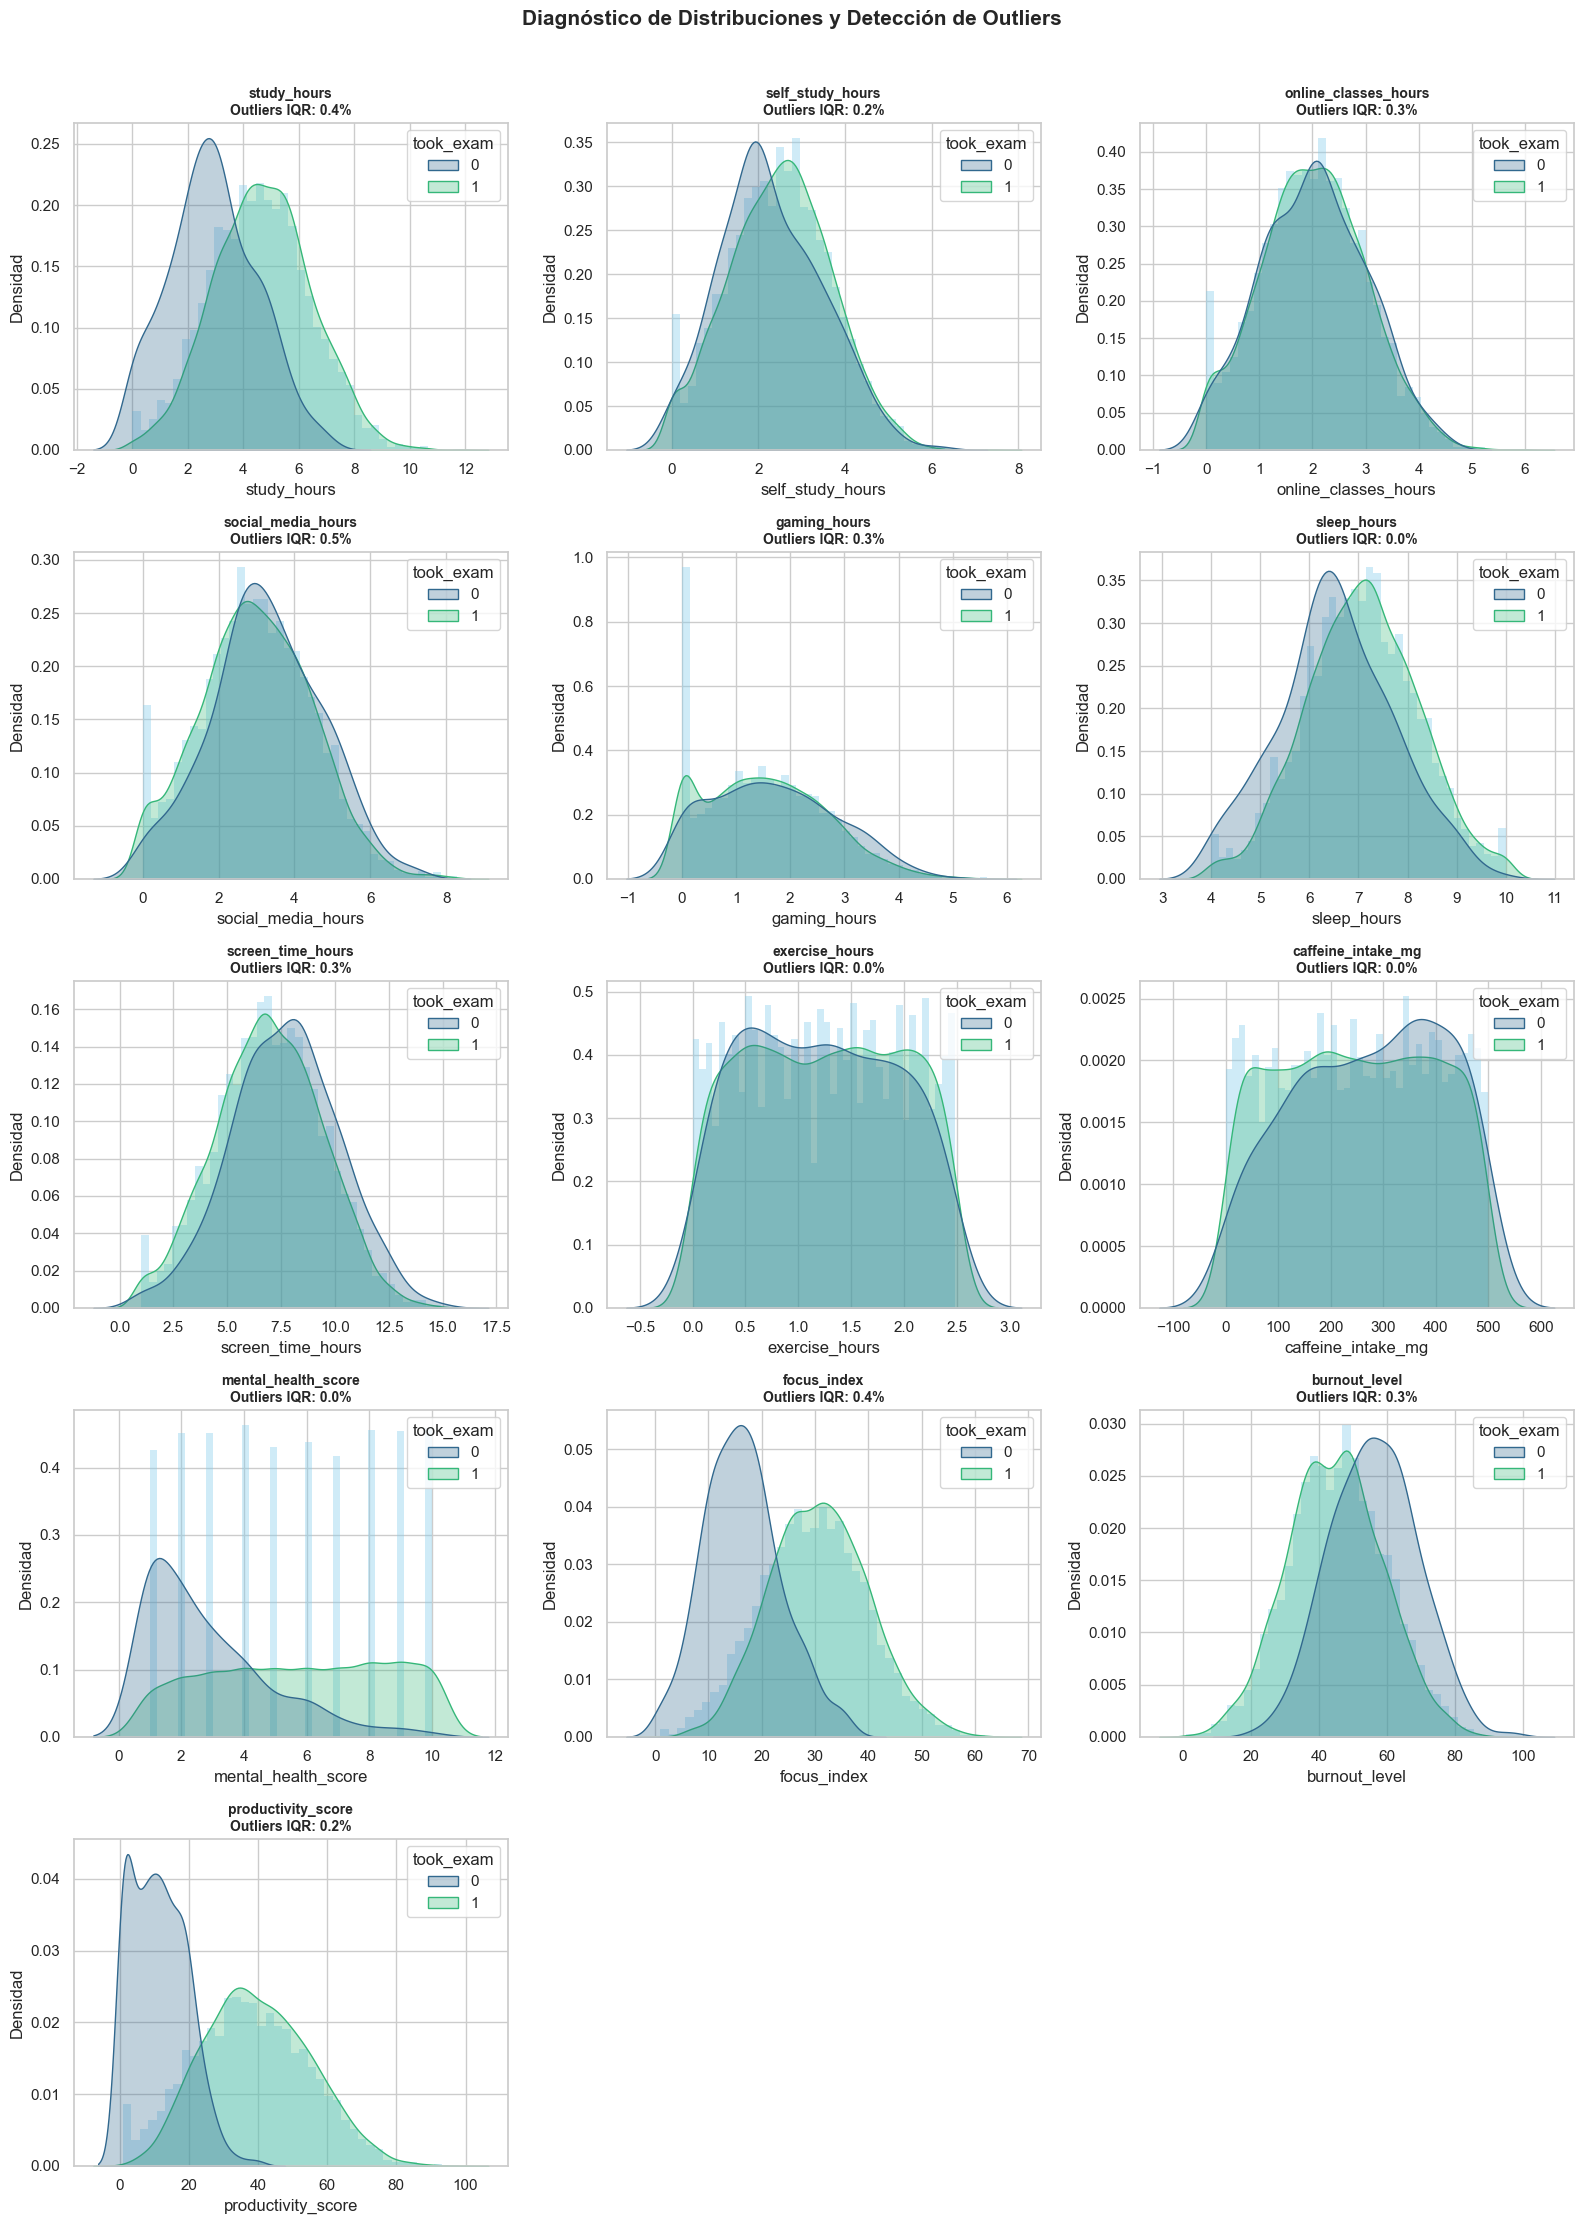

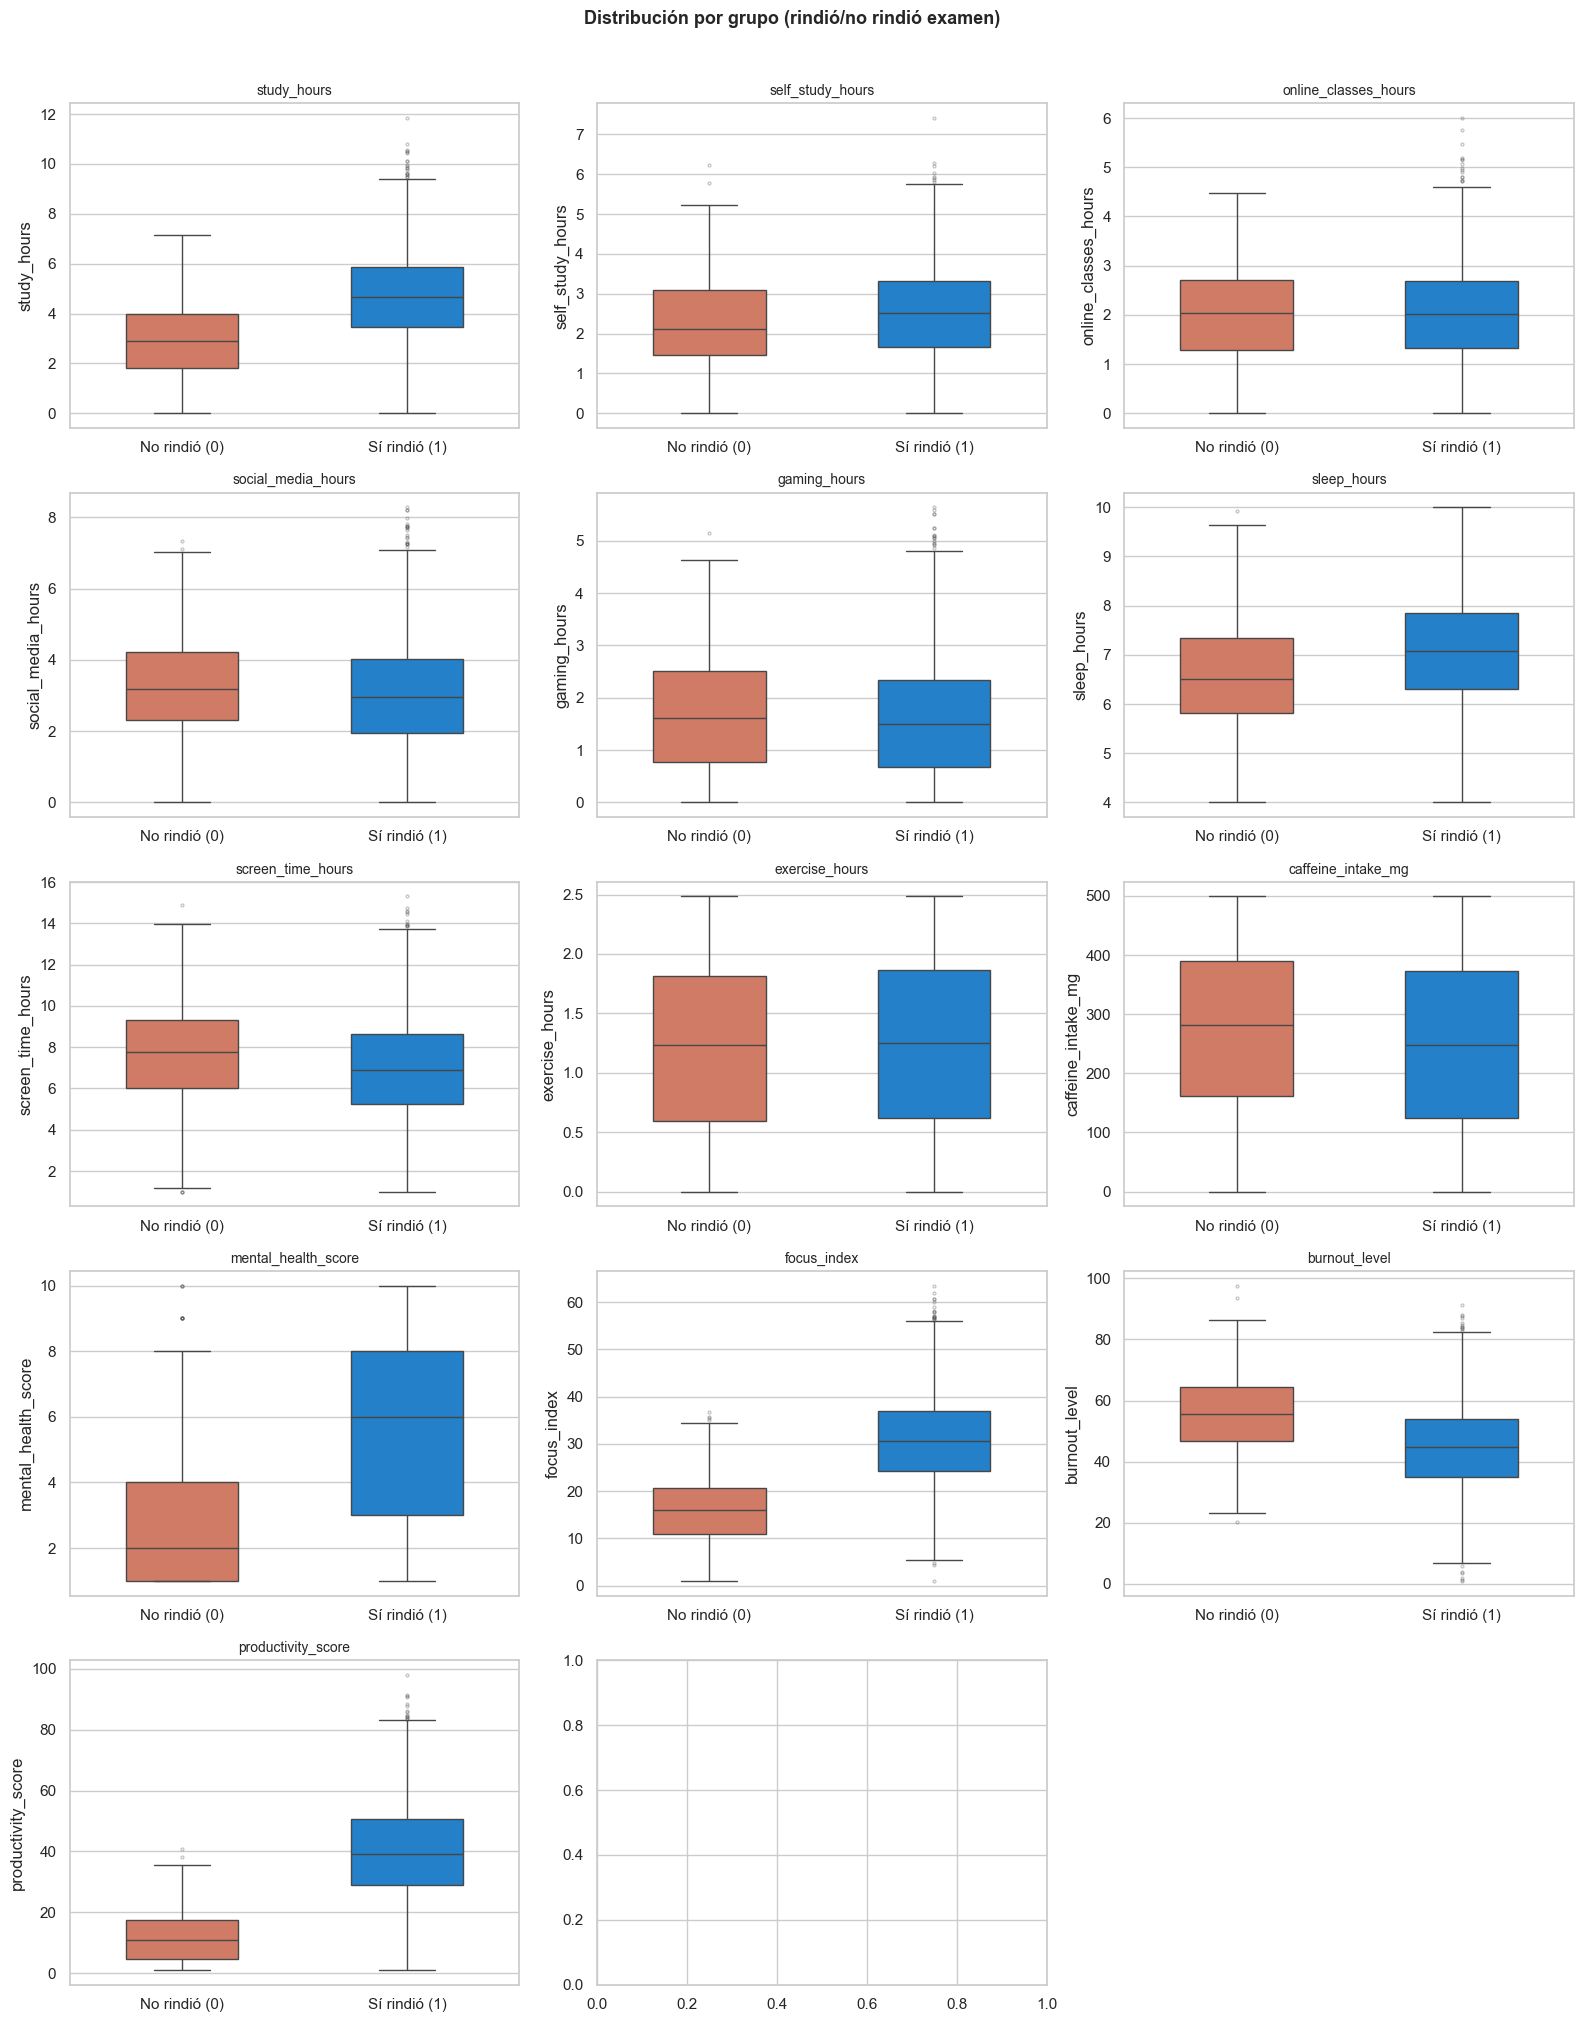

In [5]:
# 1. DEFINICIÓN DE LISTAS (Motor del análisis)
vars_plot = ["study_hours", "self_study_hours", "online_classes_hours",
             "social_media_hours", "gaming_hours", "sleep_hours",
             "screen_time_hours", "exercise_hours", "caffeine_intake_mg",
             "mental_health_score", "focus_index", "burnout_level", "productivity_score"]

cat_cols = ["gender", "academic_level", "internet_quality", 
            "upcoming_deadline", "part_time_job", "gamer"]

# Configuración estética global
sns.set_theme(style="whitegrid")
media_global = df["took_exam"].mean()

# =============================================================================
# BLOQUE 1: ANÁLISIS DIFERENCIAL DE ASISTENCIA (CATEGÓRICAS)
# =============================================================================
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 10))
axes1 = axes1.flatten()

for i, col in enumerate(cat_cols):
    ax = axes1[i]
    # Ordenar por probabilidad para detectar perfiles críticos
    order = df.groupby(col)["took_exam"].mean().sort_values(ascending=False).index
    
    sns.barplot(data=df, x=col, y="took_exam", order=order, ax=ax,
                palette="Blues_d", ci=95, capsize=0.1)
    
    ax.set_title(f"Probabilidad por {col}", fontsize=11, fontweight='bold')
    ax.axhline(media_global, color="red", linestyle="--", alpha=0.6, label=f"Media Global: {media_global:.2f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("P(asistencia)")
    ax.set_xlabel("")
    if i == 0: ax.legend(fontsize=9)

fig1.suptitle("Análisis de Perfiles: Probabilidad de Asistencia con IC 95%", 
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# BLOQUE 2: CALIDAD DE DATOS Y DISTRIBUCIONES (NUMÉRICAS)
# =============================================================================
# Ajustado para usar 'vars_plot' correctamente
fig2, axes2 = plt.subplots(5, 3, figsize=(16, 22))
axes2 = axes2.flatten()

for i, col in enumerate(vars_plot):
    ax = axes2[i]
    data = df[col].dropna()
    
    # Histograma de fondo + KDE suavizado por grupo
    ax.hist(data, bins=40, color='skyblue', alpha=0.4, density=True, edgecolor="none")
    sns.kdeplot(data=df, x=col, hue='took_exam', ax=ax, fill=True, 
                common_norm=False, palette='viridis', alpha=0.3)
    
    # Cálculo de Outliers mediante Método de Tukey (IQR)
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    pct_out = (n_out / len(data)) * 100 if len(data) > 0 else 0
    
    ax.set_title(f"{col}\nOutliers IQR: {pct_out:.1f}%", fontsize=10, fontweight='bold')
    ax.set_ylabel("Densidad")

# Apagar subplots vacíos (en la cuadrícula 5x3 sobran 2 espacios para 13 variables)
for j in range(len(vars_plot), len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle("Diagnóstico de Distribuciones y Detección de Outliers", 
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(vars_plot):
    ax = axes[i]
    sns.boxplot(data=df, x="took_exam", y=col, ax=ax, palette=["#e17055", "#0984e3"],
                width=0.5, flierprops=dict(marker="o", markersize=2, alpha=0.3))
    ax.set_xticklabels(["No rindió (0)", "Sí rindió (1)"])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

axes[-1].set_visible(False)
fig.suptitle("Distribución por grupo (rindió/no rindió examen)", 
             fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


## 1.5 Matriz de correlación


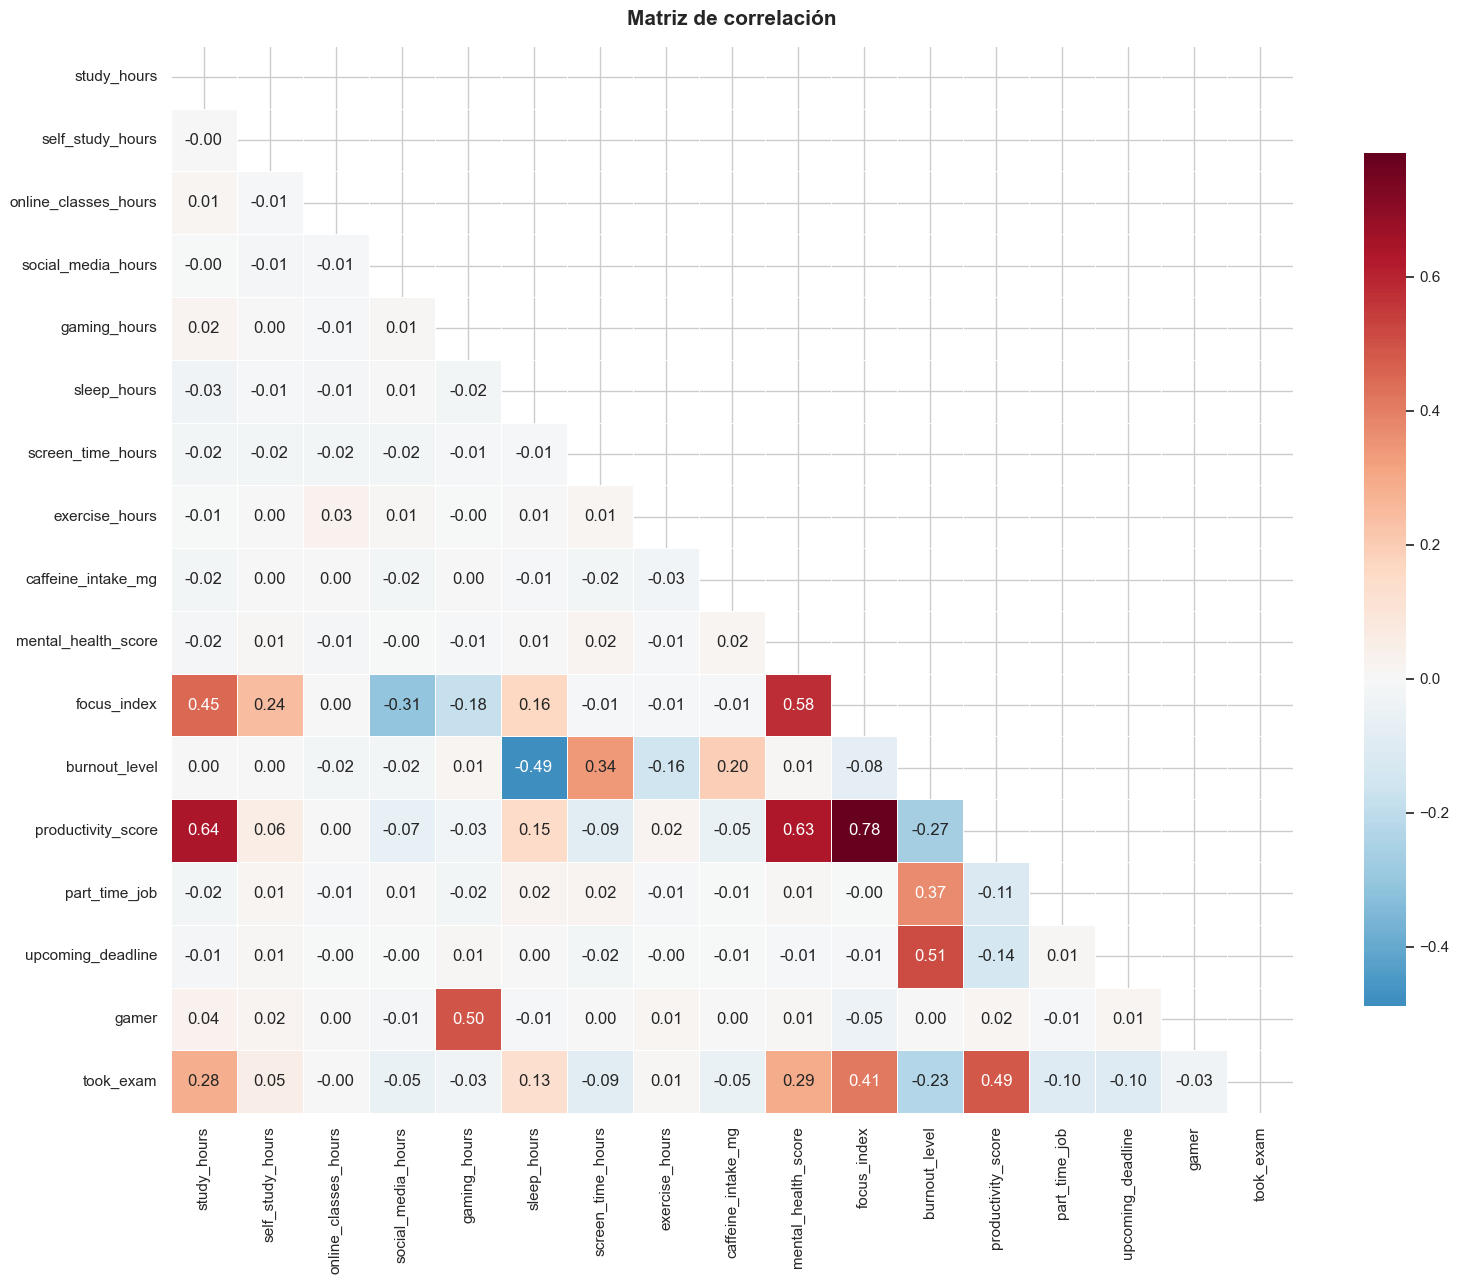


Top 8 correlaciones (|r|) con took_exam:
productivity_score    0.49
focus_index           0.41
mental_health_score   0.29
study_hours           0.28
burnout_level         0.23
sleep_hours           0.13
upcoming_deadline     0.10
part_time_job         0.10


In [6]:
corr_cols = vars_plot + ["part_time_job", "upcoming_deadline", "gamer", "took_exam"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.4, cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"size": 12})
ax.set_title("Matriz de correlación", 
             fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Top correlaciones con la VD
top_corr = corr["took_exam"].drop("took_exam").abs().sort_values(ascending=False).head(8)
print("\nTop 8 correlaciones (|r|) con took_exam:")
print(top_corr.round(4).to_string())



## 1.6 Diagnóstico de multicolinealidad (VIF)


In [7]:

vif_vars = [c for c in vars_plot if c in df.columns] + ["part_time_job", "upcoming_deadline", "gamer"]
X_vif = df[vif_vars].dropna()
X_vif_c = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    "Variable": X_vif_c.columns,
    "VIF": [variance_inflation_factor(X_vif_c.values, i) for i in range(X_vif_c.shape[1])]
}).set_index("Variable").drop("const").sort_values("VIF", ascending=False)

print("─── Variance Inflation Factor (Diagnóstico de Multicolinealidad) ───")
print("  Umbral moderado: VIF > 5  |  Umbral crítico: VIF > 10")
print("-" * 65)
print(vif_df.round(2).to_string())
print("-" * 65)


─── Variance Inflation Factor (Diagnóstico de Multicolinealidad) ───
  Umbral moderado: VIF > 5  |  Umbral crítico: VIF > 10
-----------------------------------------------------------------
                       VIF
Variable                  
productivity_score   11.53
burnout_level         6.20
mental_health_score   5.24
study_hours           5.18
focus_index           4.56
upcoming_deadline     2.46
sleep_hours           2.45
part_time_job         1.75
screen_time_hours     1.66
gaming_hours          1.45
social_media_hours    1.36
gamer                 1.34
caffeine_intake_mg    1.22
self_study_hours      1.21
exercise_hours        1.12
online_classes_hours  1.00
-----------------------------------------------------------------


### 1.7 Imputación

In [8]:
# LIMPIEZA PREVIA 
# Porque se comprobó que al imputar, tienen una variacion de la media >4, crean sesgo
df = df.dropna(subset=["part_time_job","upcoming_deadline"])

nums = df.select_dtypes(include="number").columns
cats = df.select_dtypes(include=["object","string"]).columns

# Captura pre-imputación
stats_pre    = df[nums].describe().loc[["mean","std"]].T
missing_pre  = df[nums].isnull().sum()

# Imputación
for col in nums:
    df[col] = df[col].fillna(df[col].median())
for col in cats:
    mode = df[col].mode(dropna=True)
    if not mode.empty:
        df[col] = df[col].fillna(mode[0])


# Control post-imputación
stats_post = df[nums].describe().loc[["mean","std"]].T
delta_mean = ((stats_post["mean"] - stats_pre["mean"]) / stats_pre["mean"].abs() * 100).abs()

tabla = pd.DataFrame({
    "n_imputados": missing_pre,
    "media_antes":    stats_pre["mean"],
    "media_despues":  stats_post["mean"],
    "Δmedia_%":       delta_mean,
}).loc[lambda d: d["n_imputados"] > 0].sort_values("Δmedia_%", ascending=False)



print("─── Impacto de la imputación ───────────────────────────────────────")
print(tabla.round(4).to_string())
print("-" * 65)
print("→ Variaciones < 1 % en media confirman estabilidad distribucional.")

# 6. REPORTES DE RETENCIÓN
print(f"\nDimensiones finales: {df.shape}")
print(f"Retención sobre dataset: {df.shape[0]/di2[0]*100:.2f}%")

─── Impacto de la imputación ───────────────────────────────────────
                      n_imputados  media_antes  media_despues  Δmedia_%
gamer                          90         0.89           0.89      0.24
mental_health_score            80         5.51           5.51      0.16
gaming_hours                   90         1.57           1.57      0.09
age                           108        20.52          20.53      0.06
social_media_hours            104         3.00           3.00      0.02
productivity_score             61        37.31          37.30      0.02
exercise_hours                 43         1.24           1.24      0.01
online_classes_hours           96         2.02           2.02      0.01
burnout_level                 112        45.66          45.67      0.00
caffeine_intake_mg             68       251.98         251.99      0.00
study_hours                    71         4.53           4.53      0.00
screen_time_hours              33         6.99           6.99      

## Modelo 

$$\begin{aligned}
P(\text{Rindió examen}) = \beta_0 &+ \beta_1 \text{Estudio} + \beta_2 \text{Estudio}^2 + \beta_3 \text{Sueño} + \beta_4 (\text{Estudio} \times \text{Sueño}) \\
&+ \beta_5 \text{Ejercicio} + \beta_6 \text{Gaming} + \beta_7 \text{Redes\_sociales} \\
&+ \beta_8 Z(\text{Productividad}) + \beta_9 Z(\text{Salud\_mental}) \\
&+ \beta_{10} \text{Deadline} + \beta_{11} \text{Trabajo} \\
&\text{C}(\text{NivelAcademico}) + \epsilon
\end{aligned}$$



El modelo se diseño a partir de supuestos/hipotesis listadas a continuación. 
| Hipótesis | Variable(s)  |
|---|---|
| La probabilidad de asistir crece a medida que aumentan las horas de sueño | sleep_hours |
| Las horas de estudio afectan en la asistencia, pero despues de cierta cantidad de horas el beneficio marginal disminuye, sugiriendo punto de saturación | study_hours² |
| El efecto positivo de las horas de estudio depende de las horas de sueño (complementariedad) | study_hours × sleep_hours | + |
| Las actividades extracurriculares (gaming, exercise y social media) compiten directamente con la decisión de ir a rendir el examen. | gaming_hours, social_media_hours, `exercise_hours` |
| Factores fuera del control del estudiante (presión de fechas y compromisos laborales) reducen la probabilidad de presentarse | part_time_job, upcoming_deadline |
| La disposición psicológica es un predictor clave, y al estandarizarlos, busco comparar cuál de los dos "pesa" más en la decisión | focus_index, mental_health_score |

La variable demográfica `academic_level` se incluyen como controles aunque el EDA no mostró separación fuerte entre grupos.



In [9]:
# Ecuación del Modelo
formula_mco = """
    took_exam ~ 
    study_hours + I(study_hours**2) +  
    sleep_hours + study_hours:sleep_hours + 
    exercise_hours + gaming_hours + social_media_hours 
    + standardize(focus_index) 
    + standardize(mental_health_score) 
    + upcoming_deadline + part_time_job 

    + C(academic_level, Treatment(reference='Undergraduate'))
"""

### 2. Modelo de probabilidad lineal 


In [10]:
# Ajuste del Modelo con Errores Estándar Robustos (HC1)
modelo_mco = smf.ols(formula_mco, data=df).fit(cov_type='HC1')
print("RESULTADOS: MODELO DE PROBABILIDAD LINEAL (MCO)")
print(modelo_mco.summary())

RESULTADOS: MODELO DE PROBABILIDAD LINEAL (MCO)
                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     57.08
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.20e-138
Time:                        15:26:32   Log-Likelihood:                -93.424
No. Observations:                4548   AIC:                             214.8
Df Residuals:                    4534   BIC:                             304.8
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------

### 2.1 Interpretación de resultados 

El modelo de probabilidad lineal presenta una bondad de ajuste ($R^2$) de 0.253, es decir, el modelo explica el 25.3% de la decisión de rendir el examen. La significancia global del modelo ($F\text{-stat} < 0.01$) indica que predictores elegidos tienen un impacto real en la probabilidad de rendir el examen. 

Cabe destacar que el Intercepto no resultó significativo ($p = 0.402$), lo que sugiere que ante la ausencia total de factores de preparación y bienestar, la probabilidad base de asistencia tiende a cero. Finalmente, el uso de errores robustos HC1 garantiza la validez de las inferencias realizadas frente a posibles problemas de heterocedasticidad



| **Variable(s)** | **Interpretación** |
|---|---|
| **study_hours** | Una hora de estudio adicional aumenta en $20.3$ puntos porcentuales la probabilidad de asistir al examen. Este es el motor principal de decision de asistir al examen.|
| **study_hours²** | El valor negativo (-0.0092) indica que existen rendimientos decrecientes. Una hora adicional aumenta la probabilidad, pero el beneficio marginal cae a medida que suma horas. Tras un punto de saturación (aprox. 11 hrs) hace que la probabilidad de asistir empiece a disminuir |
| **sleep_hours** | Dormir una hora adicional aumenta en 8.4 puntos porcentuales la probabilidad de asistir al examen. Esto confirma la hipotesis de que el descanso es un habilitador crítico, y que no es aconsejable sacrificar horas de sueño. |
| **study_hours × sleep_hours** | El signo negativo ($-0.0129$) indica que las horas de estudio y el sueño actúan como sustitutos, es decir, si ya estudia mucho, el efecto "extra" de dormir más es menor (y viceversa)  |
| **gaming_hours, social_media_hours, exercise_hours** | No son significativos ($p > 0.05$). Se rechaza la idea de que estas actividades compitan directamente con la asistencia|
|**part_time_job, upcoming_deadline** | Tener un trabajo part-time o una entrega próxima reduce la probabilidad de asistir en un 5.13% y 5.47% respectivamente |
| **focus_index, mental_health_score** | focus_index pesa un 57% más ($0.067 / 0.043$) que una mejora similar en salud mental, es decir, estar concentrado es mucho más determinante para asistir que la salud mental. |





## 3. Probit

In [11]:
modelo_probit = smf.probit(formula_mco, data=df).fit(disp=False)
print("══ RESULTADOS: MODELO PROBIT ══")
print(modelo_probit.summary())
ame_probit = modelo_probit.get_margeff()
print("─── Efectos Marginales Promedio (AME) — Probit ─────────────────────")
print(ame_probit.summary())


══ RESULTADOS: MODELO PROBIT ══
                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4548
Model:                         Probit   Df Residuals:                     4534
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4773
Time:                        15:26:32   Log-Likelihood:                -717.62
converged:                       True   LL-Null:                       -1372.9
Covariance Type:            nonrobust   LLR p-value:                2.847e-272
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                               

## 3.1 Interpretación de resultados 

El modelo presenta una bondad de ajuste (McFadden Pseudo-$R^2$) de 0.4773, es decir, el modelo explica el 47.73% de la decisión de rendir el examen. La significancia global del modelo ($LLR \text{ p-value} < 0.01$) indica que los predictores elegidos tienen un impacto real en la probabilidad de rendir el examen.


| **Variable(s)** | **Interpretación efectos marginales** |
|---|---|
| **study_hours** | Una hora extra de estudio diario eleva la probabilidad de asistir al examen en 3.9 puntos porcentuales.|
| **study_hours²** | No resultó estadísticamente significativo ($p = 0.434$), lo que sugiere que, bajo este modelo, la probabilidad de asistencia no presenta una curvatura de saturación tan marcada como se hipotetizó originalmente. |
| **sleep_hours** |  Dormir una hora adicional aumenta la probabilidad de asistir en 2.7 puntos porcentuales |
| **study_hours × sleep_hours** |  No significativa ($p = 0.869$). El impacto de estudiar en la asistencia no varía según las horas de sueño del alumno. |
| **gaming_hours, social_media_hours, exercise_hours** |Ninguna de estas variables de ocio o actividad física resultó significativa ($p > 0.05$). Se rechaza la hipótesis de que estas actividades compiten o restan probabilidad de asistencia al examen.|
|**part_time_job, upcoming_deadline** | Son barreras críticas: tener una entrega próxima reduce la probabilidad de asistir en 5.9 puntos porcentuales, mientras que poseer un empleo parcial la reduce en 5.0 puntos porcentuales.|
| **focus_index, mental_health_score** | Son los predictores más potentes: una mejora de una desviación estándar en el foco aumenta la probabilidad en 6.4%, mientras que en salud mental lo hace en 5.4%. Ambos son determinantes psicológicos vitales. |




### 4. Modelo Logit


In [12]:
modelo_logit = smf.logit(formula_mco, data=df).fit(disp=False)
print("══ RESULTADOS: MODELO LOGIT ══")
print(modelo_logit.summary())

ame_logit = modelo_logit.get_margeff()
print("─── Efectos Marginales Promedio (AME) — Logit ──────────────────────")
print(ame_logit.summary())

# ── Odds Ratios ───────────────────────────────────────────────────────────────
ci = modelo_logit.conf_int()
or_df = pd.DataFrame({
    "OR":       np.exp(modelo_logit.params),
    "IC 2.5 %": np.exp(ci[0]),
    "IC 97.5 %":np.exp(ci[1]),
    "p-value":  modelo_logit.pvalues,
    "Sig":      modelo_logit.pvalues.map(lambda p:"***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""),
}).drop("Intercept")

print("\n─── Odds Ratios ────────────────────────────────────────────────────")
print(or_df.round(4).to_string())
print(f"\nMcFadden Pseudo-R²: {1 - modelo_logit.llf/modelo_logit.llnull:.4f}")


══ RESULTADOS: MODELO LOGIT ══
                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4534
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4754
Time:                        15:26:32   Log-Likelihood:                -720.18
converged:                       True   LL-Null:                       -1372.9
Covariance Type:            nonrobust   LLR p-value:                3.623e-271
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                

### 4.1 Interpretación de resultados 

El modelo Logit presenta una bondad de ajuste (McFadden Pseudo-$R^2$) de 0.4754, lo que indica que el modelo explica el 47.54% de la decisión de rendir el examen. La alta significancia global ($LLR \text{ p-value} < 0.01$) confirma que los predictores son robustos para explicar el fenómeno.


| **Variable(s)** | **Interpretación efectos marginales** |
|---|---|
| **study_hours** | Un aumento de una hora de estudio diario incrementa la probabilidad de asistir en 3.29 puntos porcentuales. Su Odds Ratio de 2.01 indica que, por cada hora extra, las chances (odds) de asistir se duplican.|
| **study_hours²** | no resulta significativo ($p = 0.699$), sugiriendo que el efecto es lineal, al contrario de la hipotesis planteada |
| **sleep_hours** |  Una hora extra de sueño aumenta la probabilidad de asistir en 2.62 puntos porcentuales. El OR de 1.75 indica que las chances de asistir aumentan un 75% por cada hora adicional de sueño|
| **study_hours × sleep_hours** |  La interacción no es significativa ($p = 0.903$), reforzando que ambos factores operan de manera independiente en la decisión del estudiante.|
| **gaming_hours, social_media_hours, exercise_hours** | El gaming, las redes sociales y el ejercicio no tienen impacto significativo ($p > 0.05$). Se descarta que estas actividades compitan con la intención de asistir.|
|**part_time_job, upcoming_deadline** | El OR de 0.30 (deadline) y 0.34 (trabajo) significan que estas variables reducen las chances de asistir en un 70% y 66% respectivamente|
| **focus_index, mental_health_score** | Son los determinantes más críticos. El focus tiene un OR de 3.97 y la salud mental de 3.17. Esto significa que mejorar el focus triplica las posibilidades de asistencia |




In [13]:
# Ver resúmenes
print("--- RESUMEN MCO ---")
print(modelo_mco.summary())
print("\n--- RESUMEN PROBIT ---")
print(modelo_probit.summary())
print("\n--- RESUMEN LOGIT ---")
print(modelo_logit.summary())

--- RESUMEN MCO ---
                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     57.08
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.20e-138
Time:                        15:26:32   Log-Likelihood:                -93.424
No. Observations:                4548   AIC:                             214.8
Df Residuals:                    4534   BIC:                             304.8
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

### 5. Comparación MPL, Probit y Logit 

**¿Cuáles y por qué existen las diferencias entre los resultados?**

La bondad de ajuste de  $R^2$ del MCO es 0.25, mientras que el Pseudo-$R^2$ de Probit/Logit sube a 0.47, es decir, los modelos no lineales explican mucho mejor el comportamiento, con casi el doble de mejora.

El MPL es poco realista, ya que a veces predice cosas imposibles (como probabilidades negativas) al tratar de ajustar todo a una línea recta. En cambio, Logit y Probit son mucho más precisos porque reconocen que el impacto de las variables no es siempre el mismo ni lineal, y encierran lso resultados entre 0 y 1

**En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué?**

Logit, porque es el que mejor se adapta a la realidad, asegurando que las probabilidades siempre tengan sentido (entre 0 y 1). Además, permite hablar de "chances" de éxito; por ejemplo, nos deja decir que un buen focus_index casi cuadriplica las posibilidades de que un alumno asista. Es el modelo que mejor explica qué pasa sin complicar las cosas de más, cumpliendo con los estándares técnicos más altos.

**¿Qué variables resultaron ser robustas a la especificación?**

Study_hours, sleep_hours, focus_index y mental_health_score siempre ayudan a que el alumno se presente. Por el contrario, tener un trabajo o entregas de otras materias siempre actúan como frenos. Un gran hallazgo es que jugar o usar redes sociales no tienen significancia estadística.

## 6. Modelo Poisson para la nota del examen

In [14]:
df_2 = df[df['took_exam'] == 1].copy() # hago una copia del df solo con los que dieron el examen 

# Ecuación del Modelo
formula_notas = """
    exam_score ~ 
    study_hours + I(study_hours**2) +  
    sleep_hours + study_hours:sleep_hours + 
    exercise_hours + gaming_hours + social_media_hours 
    + standardize(focus_index) 
    + standardize(mental_health_score) 
    + upcoming_deadline + part_time_job 
    + C(academic_level, Treatment(reference='Undergraduate'))
"""

modelo_poisson = smf.poisson(formula_notas, data=df_2).fit(disp=False)
print("══ RESULTADOS: MODELO POISSON ══")
print(modelo_poisson.summary())



══ RESULTADOS: MODELO POISSON ══
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4140
Model:                        Poisson   Df Residuals:                     4126
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3843
Time:                        15:26:33   Log-Likelihood:                -14317.
converged:                       True   LL-Null:                       -23252.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                              

In [15]:
# El modelo Poisson es ideal para variables de respuesta que son razones o conteos positivos
modelo_poisson = smf.poisson(formula_notas, data=df_2).fit(cov_type='HC1')

print("--- RESULTADOS MODELO POISSON (NOTAS) ---")
print(modelo_poisson.summary())

# 4. Cálculo de efectos marginales para interpretar en "puntos de nota"
mfx_notas = modelo_poisson.get_margeff()
print("\n--- EFECTOS MARGINALES (Cambio en puntos de nota) ---")
print(mfx_notas.summary())

Optimization terminated successfully.
         Current function value: 3.458249
         Iterations 6
--- RESULTADOS MODELO POISSON (NOTAS) ---
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4140
Model:                        Poisson   Df Residuals:                     4126
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3843
Time:                        15:26:33   Log-Likelihood:                -14317.
converged:                       True   LL-Null:                       -23252.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

### 6.1 Interpretación de resultados
El modelo presenta un ajuste (Pseudo-$R^2$) de 0.3843, lo que indica una buena capacidad para explicar la variabilidad de las notas. Sin embargo, el Ratio Varianza/Media de 6.20 advierte que los resultados de significancia (p-values) podrían estar inflados por la sobredispersión.


| **Variable(s)** | **Interpretación efectos marginales** |
|---|---|
| **study_hours** | Una hora extra de estudio aumenta la nota en 6,33 puntos, siendo el factor con mayor impacto directo.|
| **study_hours²** | El signo negativo (-0.18) confirma rendimientos decrecientes: estudiar demasiado satura y aporta cada vez menos.|
| **sleep_hours** |  Dormir una hora adicional sube la nota en 3,48 puntos. El descanso es una inversión directa en el rendimiento.|
| **study_hours × sleep_hours** | El efecto negativo (-0.31) indica que el beneficio del sueño disminuye si el estudio es excesivo (y viceversa)|
| **gaming_hours, social_media_hours, exercise_hours** |El ejercicio físico sí aporta positivamente (0.8 pts), mientras que el gaming y redes sociales no tienen un impacto significativo|
|**part_time_job, upcoming_deadline** | Tener entregas próximas resta 4,77 puntos y tener trabajo resta 3,48 puntos|
| **focus_index, mental_health_score** | Influye más el foco (4.21 pts) que el bienestar emocional (3.87 pts) en la nota|

---
## 7. Diagnóstico de sobredispersión y estimación del parámetro $\alpha$


In [16]:
mean_y = df_2['exam_score'].mean()
var_y = df_2['exam_score'].var()

print(f"Media de la nota: {mean_y:.2f}")
print(f"Varianza de la nota: {var_y:.2f}")
print(f"Ratio Varianza/Media: {var_y/mean_y:.2f}")

# Usamos la misma fórmula pero en el formato de la librería 'statsmodels.api' para NB
# El modelo NegBinomial en statsmodels usa por defecto el parámetro 'alpha'
modelo_nb = smf.negativebinomial(formula_notas, data=df_2).fit()

print(modelo_nb.summary())

# El valor de alpha estimado
alpha_optim = modelo_nb.params['alpha']
print(f"\nEl valor óptimo de alpha estimado es: {alpha_optim:.4f}")

Media de la nota: 20.58
Varianza de la nota: 127.52
Ratio Varianza/Media: 6.20
Optimization terminated successfully.
         Current function value: 3.299607
         Iterations: 29
         Function evaluations: 39
         Gradient evaluations: 39
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 4140
Model:               NegativeBinomial   Df Residuals:                     4126
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1361
Time:                        15:26:33   Log-Likelihood:                -13660.
converged:                       True   LL-Null:                       -15812.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|  

Ratio Var/Media = 6.1956
→ El Poisson asume ratio = 1.0. Un ratio de 6.20 implica sobredispersión severa.

─── Test de Cameron–Trivedi (1990) ──────────────────────────────────
  H₀: α = 0  (Poisson / equidispersión)
  α estimado: 133.286425
  t-estadístico: 84.4361
  p-value:       0.000e+00
  → RECHAZA H₀ → sobredispersión estadísticamente significativa


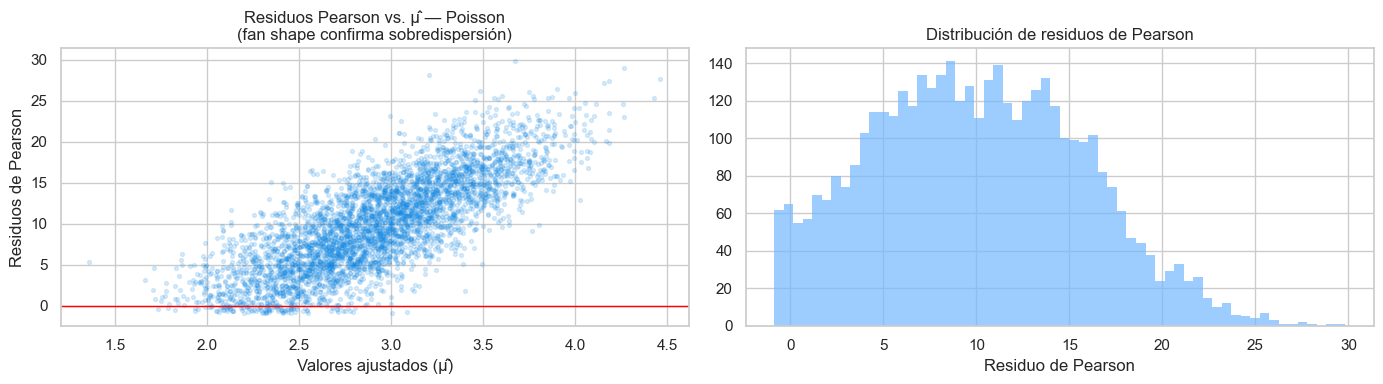

In [17]:
mu_y  = df_2["exam_score"].mean()
var_y = df_2["exam_score"].var()

# ── 1. Ratio Var/Media ────────────────────────────────────────────────────────

print(f"Ratio Var/Media = {var_y/mu_y:.4f}")
print(f"→ El Poisson asume ratio = 1.0. Un ratio de {var_y/mu_y:.2f} implica sobredispersión severa.\n")

# ── 2. Test de Cameron–Trivedi ────────────────────────────────────────────────
mu_hat = modelo_poisson.fittedvalues
y_obs  = df_2["exam_score"].values
aux_y  = (y_obs - mu_hat)**2 - y_obs
aux_X  = sm.add_constant(mu_hat**2)

ct = sm.OLS(aux_y, aux_X).fit()
alpha_ct = ct.params.iloc[1]
t_ct     = ct.tvalues.iloc[1]
p_ct     = ct.pvalues.iloc[1]

print("─── Test de Cameron–Trivedi (1990) ──────────────────────────────────")
print(f"  H₀: α = 0  (Poisson / equidispersión)")
print(f"  α estimado: {alpha_ct:.6f}")
print(f"  t-estadístico: {t_ct:.4f}")
print(f"  p-value:       {p_ct:.3e}")
if p_ct < 0.05:
    print("  → RECHAZA H₀ → sobredispersión estadísticamente significativa")
else:
    print("  → No rechaza H₀")

# ── 3. Visualización residuos de Pearson ─────────────────────────────────────
pearson_res = (y_obs - mu_hat) / np.sqrt(mu_hat)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(mu_hat, pearson_res, alpha=0.15, s=8, color="#0984e3")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Valores ajustados (μ̂)")
axes[0].set_ylabel("Residuos de Pearson")
axes[0].set_title("Residuos Pearson vs. μ̂ — Poisson\n(fan shape confirma sobredispersión)")

axes[1].hist(pearson_res, bins=60, color="#74b9ff", edgecolor="none", alpha=0.7)
axes[1].set_xlabel("Residuo de Pearson")
axes[1].set_title("Distribución de residuos de Pearson")
plt.tight_layout(); plt.show()


|Análisis|Resultados | Conclusión|
|---|---|---|
|Relación entre media y varianza |  Media 20.49. Varianza de la nota: 126.84. Ratio Varianza/Media: 6.19 | En Poisson deberían ser iguales. La varianza es 6 veces mayor, lo que indica que las notas varían mucho más, entonces Poisson subestima los errores, dando resultados poco confiables.|
|Test de Cameron Trivedi |  $p\text{-value} = 0.000e+00$ | Se rechaza la hipótesis nula ($H_0$) de equidispersión. |
|$\alpha$ estimado | $\alpha$ = 0.0311 | El parámetro $\alpha$ captura la heterogeneidad no observada entre estudiantes, indicando que hay factores que el modelo no está viendo que causan la variación.|



## 8. Modelo Binomial Negativa (NB2)



In [20]:
# 1. Ajustar el modelo primero
modelo_nb = smf.negativebinomial(formula_notas, data=df_2).fit(disp=False)

# 2. Extraer métricas de Alpha (directamente del modelo ya ajustado)
alpha_nb = modelo_nb.params["alpha"]
ci_nb    = modelo_nb.conf_int()

print("══ RESULTADOS: MODELO BINOMIAL NEGATIVA (NB2) ══")
print(modelo_nb.summary()) 

print(f"α estimado (NB2): {alpha_nb:.6f}")
# Nota: Para alpha no se usa np.exp en el IC, se muestra el valor directo
print(f"IC 95 % alpha: [{ci_nb.loc['alpha', 0]:.6f}, {ci_nb.loc['alpha', 1]:.6f}]")
print(f"p-value α: {modelo_nb.pvalues['alpha']:.4e}")
print("→ α significativamente distinto de cero confirma que NB2 > Poisson.\n")

# 3. ── IRR y efectos marginales NB2 

# Extraemos los efectos marginales (que no incluyen Intercept ni Alpha)
marg_eff = modelo_nb.get_margeff().margeff

# Filtramos los parámetros para que coincidan con el largo de marg_eff (13 variables)
# Quitamos el Intercepto y el Alpha de los vectores de parámetros
params_filtered = modelo_nb.params.drop(["Intercept", "alpha"])
pvalues_filtered = modelo_nb.pvalues.drop(["Intercept", "alpha"])
ci_filtered = modelo_nb.conf_int().drop(["Intercept", "alpha"])

irr_nb = pd.DataFrame({
    "β (NB2)":     params_filtered,
    "IRR (NB2)":   np.exp(params_filtered),
    "IC 2.5 %":    np.exp(ci_filtered[0]),
    "IC 97.5 %":   np.exp(ci_filtered[1]),
    "EM (puntos)": marg_eff,
    "p-value":     pvalues_filtered,
    "Sig":         pvalues_filtered.map(lambda p:"***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""),
})

print("─── IRR y Efectos Marginales — NB2 ──────────────────────────────────")
print(irr_nb.round(5).to_string())

══ RESULTADOS: MODELO BINOMIAL NEGATIVA (NB2) ══
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 4140
Model:               NegativeBinomial   Df Residuals:                     4126
Method:                           MLE   Df Model:                           13
Date:               mié, 22 abr. 2026   Pseudo R-squ.:                  0.1361
Time:                        15:29:51   Log-Likelihood:                -13660.
converged:                       True   LL-Null:                       -15812.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                              

### 8.1 Interpretación de resultados
El parámetro $\alpha$ resultó ser 0.0606 con un $p\text{-value}$ cercano a cero, lo que valida que este modelo es superior al Poisson para explicar las notas.


| **Variable** | **Interpretación** |
|---|---|
| study_hours | Cada hora extra de estudio sube la nota directamente. Es el predictor de mayor impacto en el rendimiento académico. | 
| study_hours² | Los rendimientos son decrecientes: las primeras horas son muy productivas, pero pasadas 11 horas decrece |
| sleep_hours | Dormir una hora más sube la nota en 3.6 puntos. El sueño no es un lujo — es una inversión directa en el puntaje. | 
| study_hours:sleep_hours | Estudiar y dormir mucho simultáneamente se neutralizan parcialmente cuando se llega a niveles extremos|
| gaming_hours, social_media_hours, exercise_hours | El impacto no es robusto. El ejercicio ayuda levemente, mientras que el gaming y las redes sociales no afectan significativamente la nota.| 
| focus_index, mental_health_score | 1 σ más de concentración sube la nota en 4.6 puntos. Una sesión de 2 horas con foco total supera a 5 horas con distracciones. |
| upcoming_deadline, part_time_job | Tener una entrega próxima resta 5.3 y trabajar medio tiempo **resta 3.8 puntos**| 


In [19]:
# ── Comparación de IRR lado a lado ────────────────────────────────────────────
irr_cmp = pd.DataFrame({
    "IRR Poisson": np.exp(modelo_poisson.params),
    "p Poisson":   modelo_poisson.pvalues,
    "IRR NB2":     np.exp(modelo_nb.params),
    "p NB2":       modelo_nb.pvalues,
}).drop(["Intercept"], errors="ignore").drop(["alpha"], errors="ignore")
print("─── Comparación IRR: Poisson vs. NB2 ───────────────────────────────")
print(irr_cmp.round(5).to_string())

# ── Variables robustas al supuesto distribucional ────────────────────────────
sig_p  = set(modelo_poisson.pvalues[modelo_poisson.pvalues < 0.05].index) - {"Intercept"}
sig_nb = set(modelo_nb.pvalues[modelo_nb.pvalues < 0.05].index) - {"Intercept","alpha"}
robust_count = sig_p & sig_nb
print(f"\n─── Variables robustas (p<0.05 en ambos modelos) ───────────────────")
for v in sorted(robust_count): print(f"  ✓ {v}")

─── Comparación IRR: Poisson vs. NB2 ───────────────────────────────
                                                                         IRR Poisson  p Poisson  IRR NB2  p NB2
C(academic_level, Treatment(reference='Undergraduate'))[T.High School]          1.00       0.96     1.00   0.95
C(academic_level, Treatment(reference='Undergraduate'))[T.Postgraduate]         1.01       0.62     1.00   0.80
I(study_hours ** 2)                                                             0.99       0.00     0.99   0.00
exercise_hours                                                                  1.04       0.00     1.04   0.00
gaming_hours                                                                    1.01       0.26     1.01   0.26
part_time_job                                                                   0.84       0.00     0.83   0.00
sleep_hours                                                                     1.18       0.00     1.19   0.00
social_media_hours                 



### 9.1 Comentarios y conclusiones

**¿Cuáles y por qué existen las diferencias entre los resultados?**

Al comparar el modelo Poisson y el Binomial Negativo (NB2), la diferencia fundamental está en la precisión de la inferencia. El modelo Poisson asume que la varianza es igual a la media, pero como en este caso la varianza es 6.2 veces mayor a la media, Poisson subestima los errores estándar. Por ejemplo, en el modelo Poisson, la variable social_media_hours estaba al borde de la significancia ($p=0.06$), pero en el NB2 sube a **0.07**. NB2 es, por tanto, el único modelo válido para evitar conclusiones erróneas.

**Variables robustas al supuesto distribucional**

Las variables que no resultaron robustas fueron nivel academico, horas de gaming y horas de social media, las demás resultaron totalmente robustas, manteniendo su significancia ($p < 0.01$) y magnitudes de IRR casi iguales en ambos modelos. Esto sugiere que el impacto de factores como el **estudio (IRR 1.36)**, el **foco (IRR 1.25)** y el **sueño (IRR 1.19)** es tan real que no depende del modelo elegido. 



### 9.2 Conclusiones Estratégicas y Recomendaciones


El foco o concentración (focus_index) incrementa la nota en **4.6 puntos** por cada desviación estándar, superando incluso a la Salud Mental (**4.0 puntos**). Es preferible una sesión de estudio de 2 horas con foco máximo que una de 5 horas con distracciones. 


El coeficiente de study_hours es positivo ($+6.3$ pts/hr), pero su término cuadrático es negativo ($-0.18$) indicando un punto de saturacion aproximandamente despues de la hora 11, donde la nota a caer.


El efecto interacción study_hours:sleep_hours es negativo ($-0.32$). 
Esto rompe con la hipotesis incial e indica que si ya se estudia mucho, el beneficio de dormir una hora extra disminuye en términos marginales. Esto indica que no es recomendable sacrificar sueño por horas de estudio de baja calidad.


Los deadlines y el trabajo restan en promedio **5.2** y **3.7 puntos** respectivamente, entonces es importante balancearlos correctamente.
